In [1]:
%load_ext autoreload
%autoreload 2

In [2]:
import os, sys
import copy
from matplotlib.gridspec import GridSpec
from matplotlib.lines import Line2D
import matplotlib as mat
import matplotlib.pyplot as plt
%matplotlib inline

In [3]:
livetime_yr = 11.687
livetime_s  = livetime_yr * 365.25 * 24 * 3600 # 11.687 year

In [4]:
plotting_path = f"/data/user/tvaneede/GlobalFit/reco_processing/notebooks/documentation/plots/snowstorm"
os.system(f"mkdir -p {plotting_path}")

0

In [5]:
simulation_datasets = {}
sys.path.append("/data/user/tvaneede/GlobalFit/reco_processing")

from datasets import datasets_hese as datasets
reco_versions =  ["hese_iceprod_v7" ]
for reco_version in reco_versions: simulation_datasets[reco_version] = copy.deepcopy(getattr(datasets, reco_version))

from datasets import datasets_hese_extra as datasets
reco_versions =  ["hese_extra_iceprod_v1" ]
for reco_version in reco_versions: simulation_datasets[reco_version] = copy.deepcopy(getattr(datasets, reco_version))


In [6]:
# import opening and merging files
from open_and_merge import *

In [7]:
for key in simulation_datasets: simulation_datasets[key] = open_datasets_by_level(simulation_datasets[key],key)

----- Opening dataset NuE_highE
    -> Level HESE
    -> file /data/user/tvaneede/GlobalFit/reco_processing/hdf/output/hese_iceprod_v7/merged/HESE_NuE_22612.h5
----- Opening dataset NuE_midE
    -> Level HESE
    -> file /data/user/tvaneede/GlobalFit/reco_processing/hdf/output/hese_iceprod_v7/merged/HESE_NuE_22613.h5
----- Opening dataset NuTau_midE
    -> Level HESE
    -> file /data/user/tvaneede/GlobalFit/reco_processing/hdf/output/hese_iceprod_v7/merged/HESE_NuTau_22634.h5
----- Opening dataset NuTau_highE
    -> Level HESE
    -> file /data/user/tvaneede/GlobalFit/reco_processing/hdf/output/hese_iceprod_v7/merged/HESE_NuTau_22635.h5
----- Opening dataset NuMu_highE
    -> Level HESE
    -> file /data/user/tvaneede/GlobalFit/reco_processing/hdf/output/hese_iceprod_v7/merged/HESE_NuMu_22644.h5
----- Opening dataset NuMu_midE
    -> Level HESE
    -> file /data/user/tvaneede/GlobalFit/reco_processing/hdf/output/hese_iceprod_v7/merged/HESE_NuMu_22645.h5
----- Opening dataset NuE_highE

In [8]:
from open_and_merge import *
for key in simulation_datasets: 
    print(20*"=", key)
    simulation_datasets[key] = merge_datasets_by_level( simulation_datasets[key] )

==================== hese_iceprod_v7
----- Merging level level6_cascade
Skipping level level6_cascade, not present in any dataset
----- Merging level level6_hybrid
Skipping level level6_hybrid, not present in any dataset
----- Merging level level6_muon
Skipping level level6_muon, not present in any dataset
----- Merging level HESE_evtgen
Skipping level HESE_evtgen, not present in any dataset
----- Merging level HESE_taupede
Skipping level HESE_taupede, not present in any dataset
----- Merging level level7_cascade_evtgen
Skipping level level7_cascade_evtgen, not present in any dataset
----- Merging level HESE
----- Merging level level3_muon
Skipping level level3_muon, not present in any dataset
Skipping NuE/level6_cascade, not merged
Skipping NuMu/level6_cascade, not merged
Skipping NuTau/level6_cascade, not merged
Skipping NuAll/level6_cascade, not merged
Skipping NuE/level6_hybrid, not merged
Skipping NuMu/level6_hybrid, not merged
Skipping NuTau/level6_hybrid, not merged
Skipping NuA

check if merging works now, seems to be fine

In [9]:
from event_rate import *
for key in simulation_datasets: 
    print(20*"=", key)
    print_event_rate( simulation_dataset=simulation_datasets[key] )

==================== hese_iceprod_v7
         astro_NuE    astro_NuMu   astro_NuTau            conv        prompt
HESE  56.74 ± 0.37  20.58 ± 0.15  35.05 ± 0.28  41.469 ± 0.730  13.43 ± 0.07
==================== hese_extra_iceprod_v1
                 astro_NuE    astro_NuMu   astro_NuTau            conv        prompt
HESE_evtgen   57.49 ± 0.39  20.81 ± 0.16  35.03 ± 0.29  40.584 ± 0.716  13.59 ± 0.08
HESE_taupede  57.50 ± 0.39  20.82 ± 0.16  35.06 ± 0.29  40.646 ± 0.717  13.60 ± 0.08


Here I test my helper functions

/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/notebooks/documentation/advanced_plotting.py:158: RuntimeWarning: invalid value encountered in divide
  ratio = hist_alt / hist_base
/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/notebooks/documentation/advanced_plotting.py:175: RuntimeWarning: invalid value encountered in divide
  (hist_base_error / hist_base)**2 + (hist_alt_error / hist_alt)**2
/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/notebooks/documentation/advanced_plotting.py:184: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0.8 * np.min([hist_base.min(), hist_alt.min()]),
/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/notebooks/documentation/advanced_plotting.py:158: RuntimeWarning: divide by zero encountered in divide
  ratio = hist_alt / hist_base


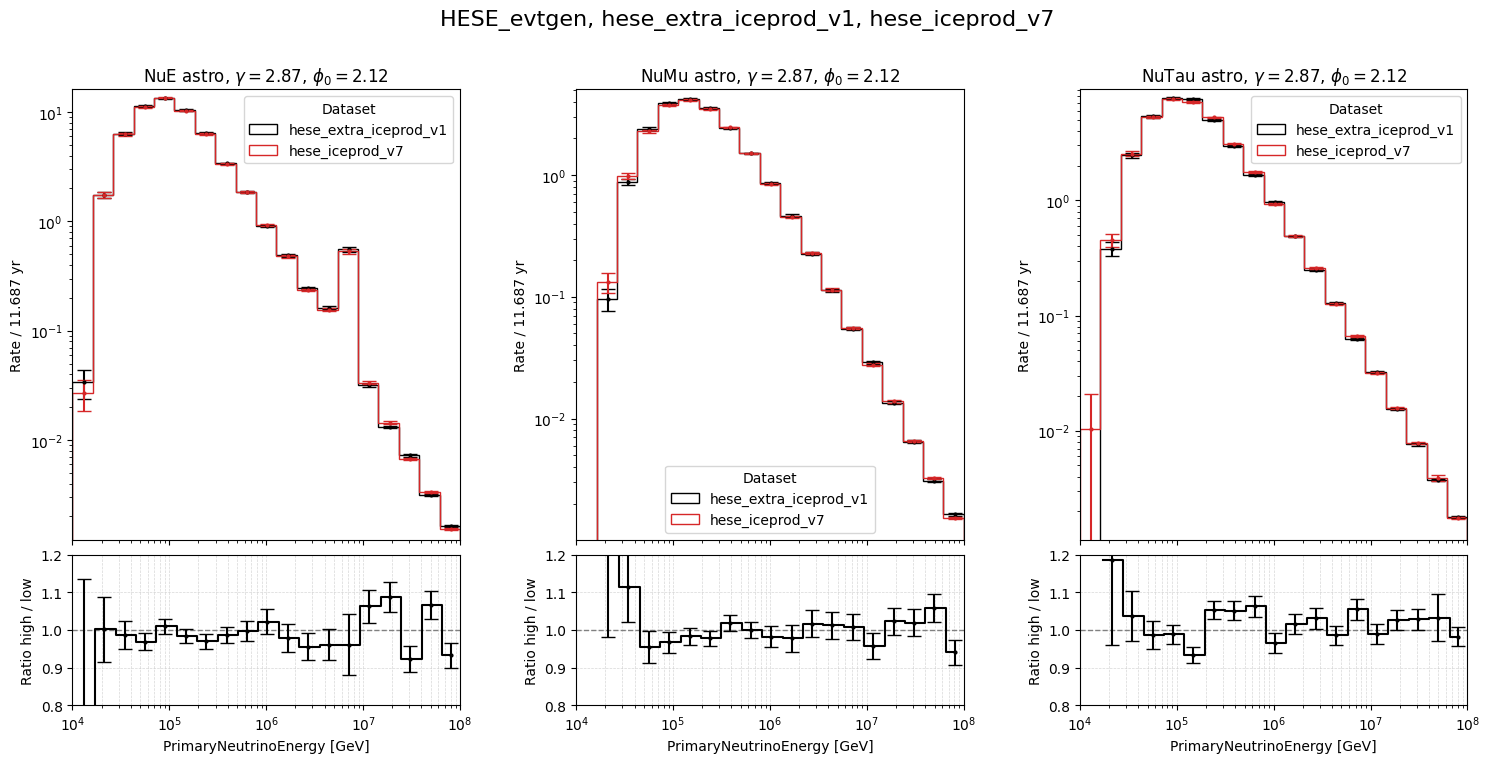

In [10]:
from advanced_plotting import *
compare_dataset_flavor(
simulation_datasets, 
base_key = "hese_extra_iceprod_v1",
base_level = "HESE_evtgen",
base_var_key1 = "I3MCWeightDict", 
base_var_key2 = "PrimaryNeutrinoEnergy",
alt_key = "hese_iceprod_v7",
alt_level = "HESE",
alt_var_key1 = "I3MCWeightDict", 
alt_var_key2 = "PrimaryNeutrinoEnergy",
variable_name = "PrimaryNeutrinoEnergy [GeV]",
bins = np.geomspace(1e4, 1e8, 20),
xscale = "log", yscale = "log", 
livetime_yr = 11.687,
flux_gamma = 2.87,
flux_norm  = 2.12,
plotting_path = None)


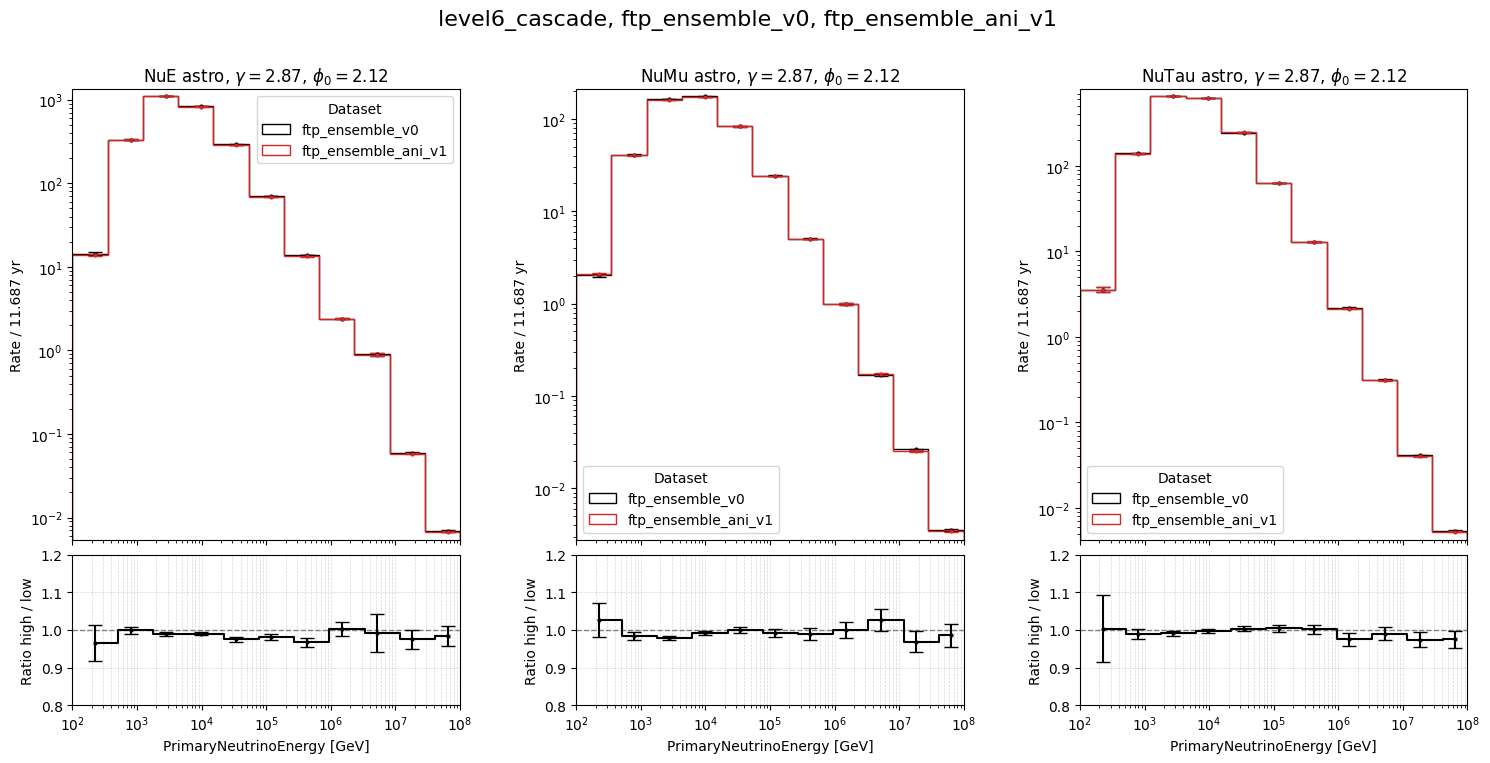

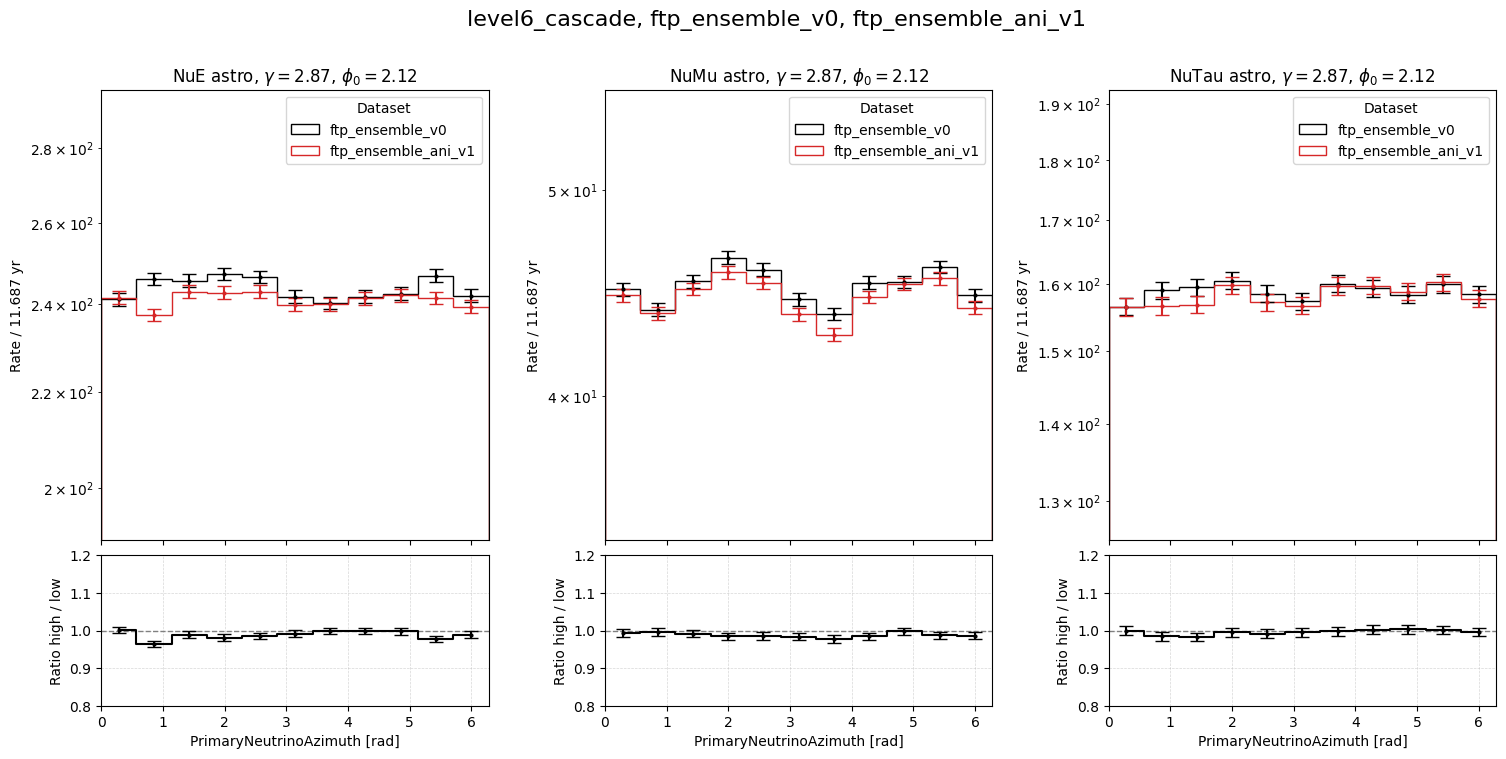

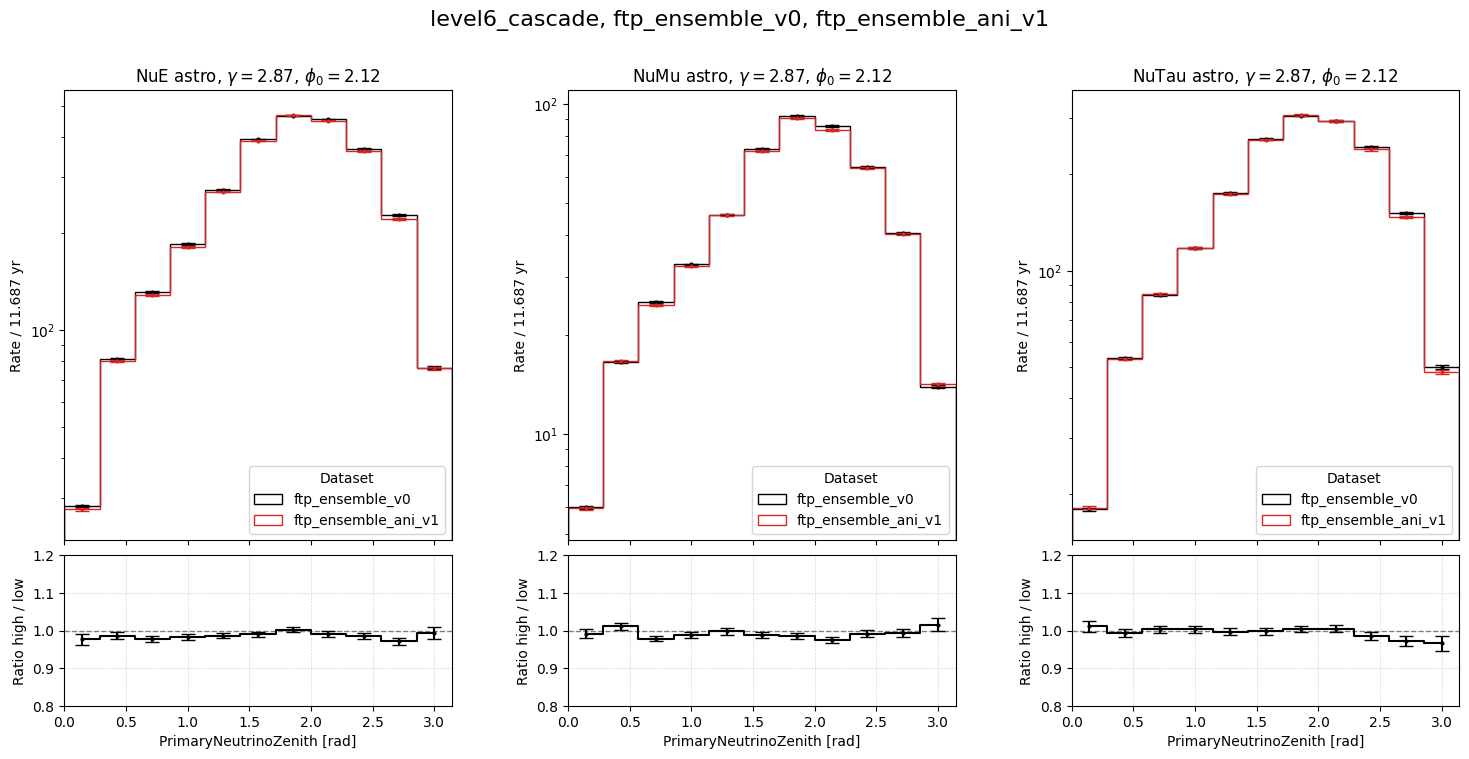

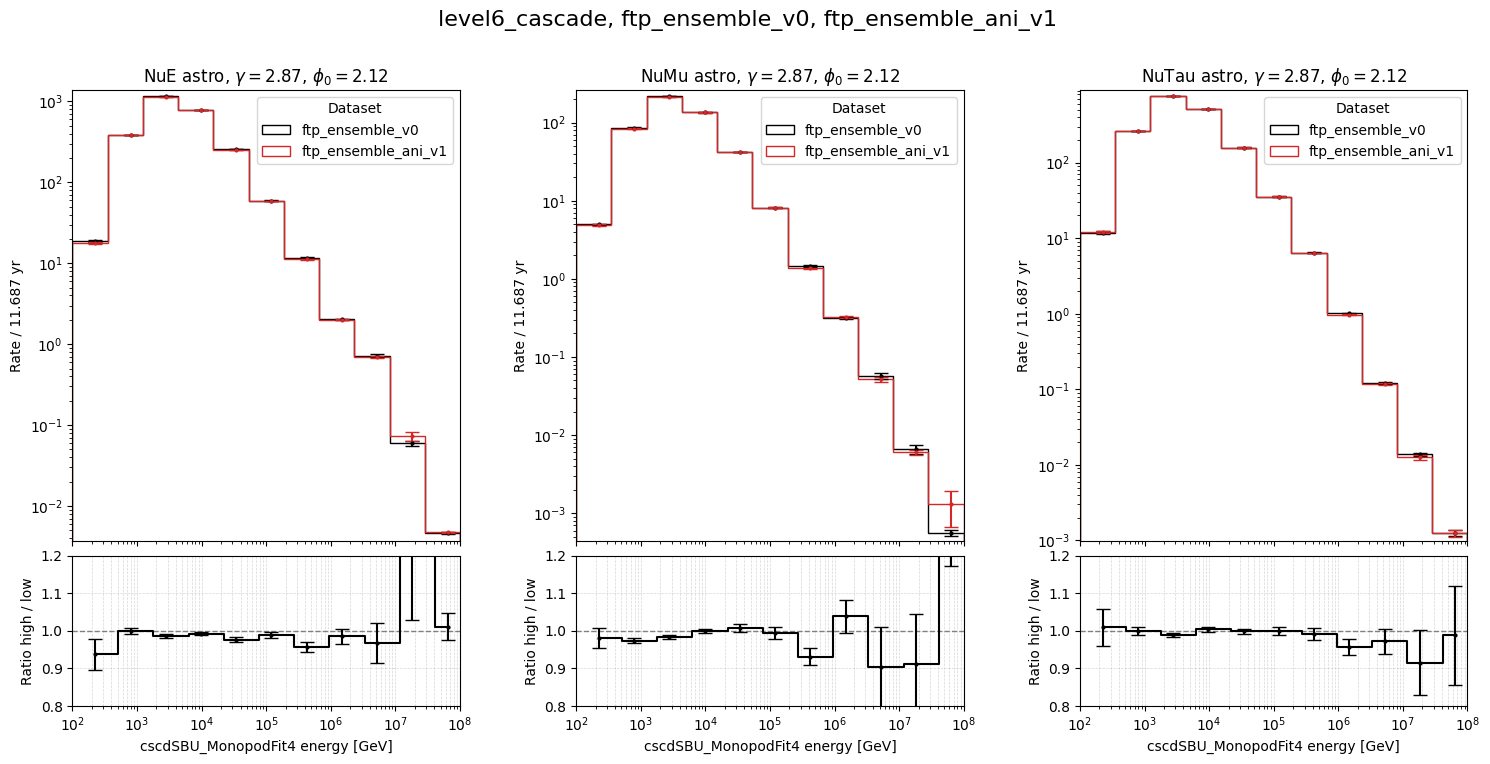

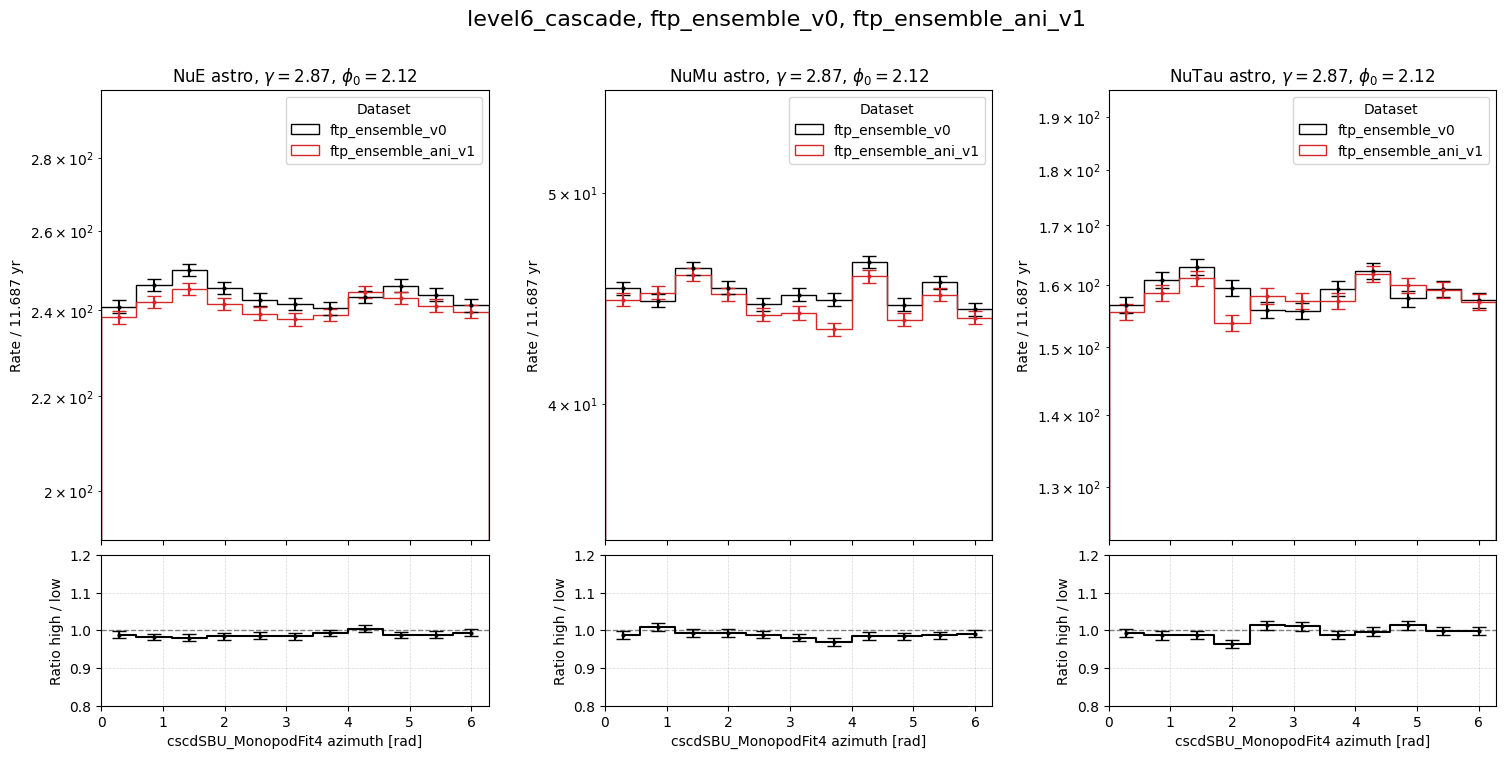

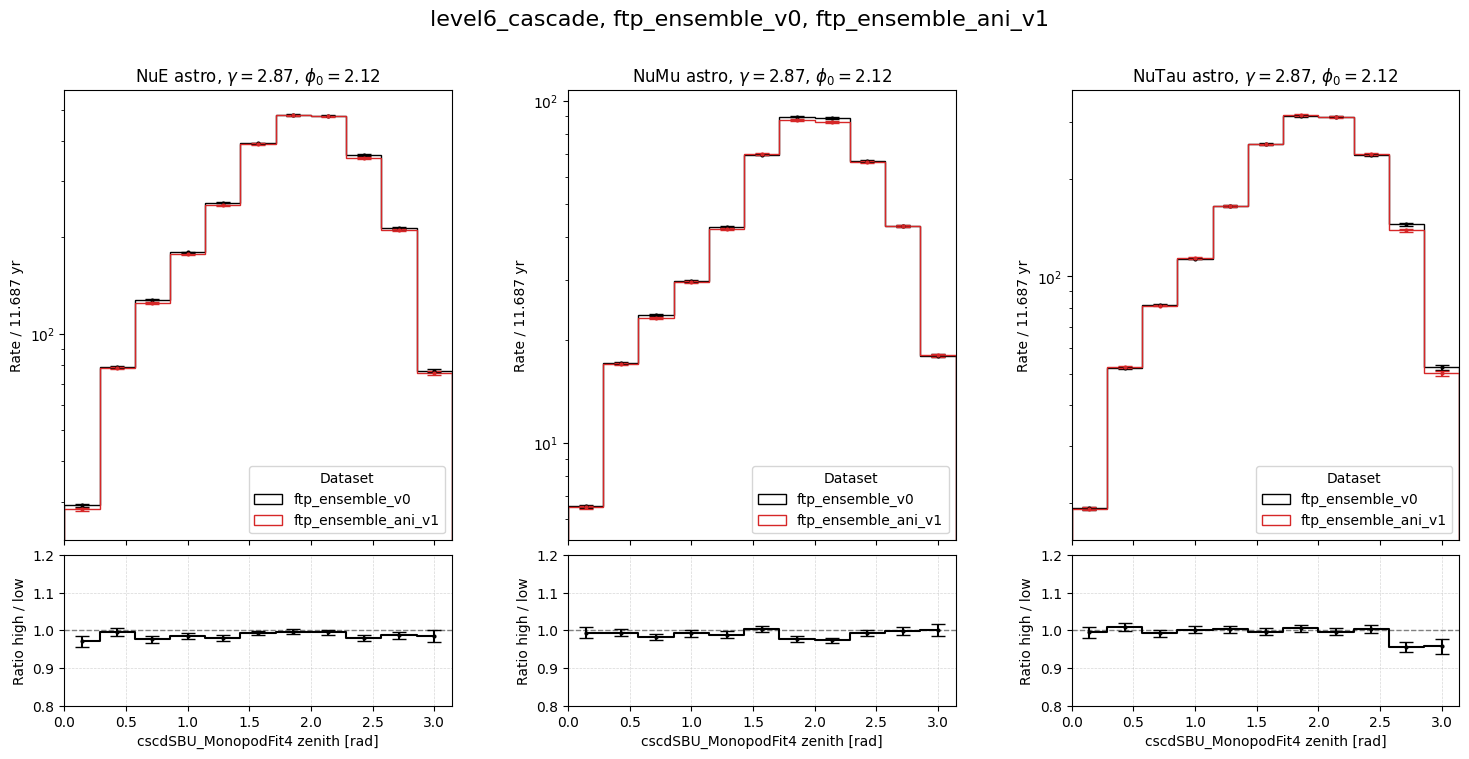

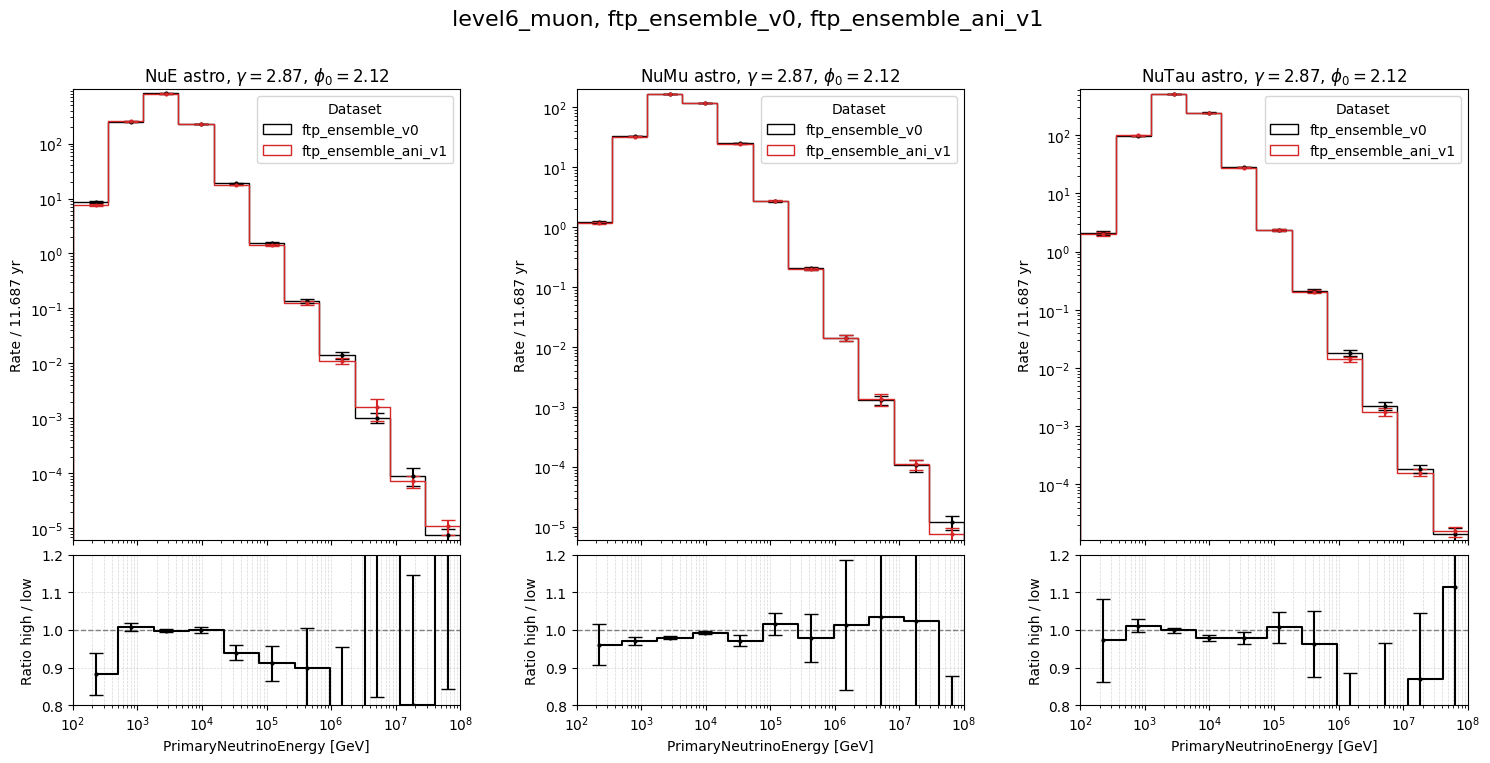

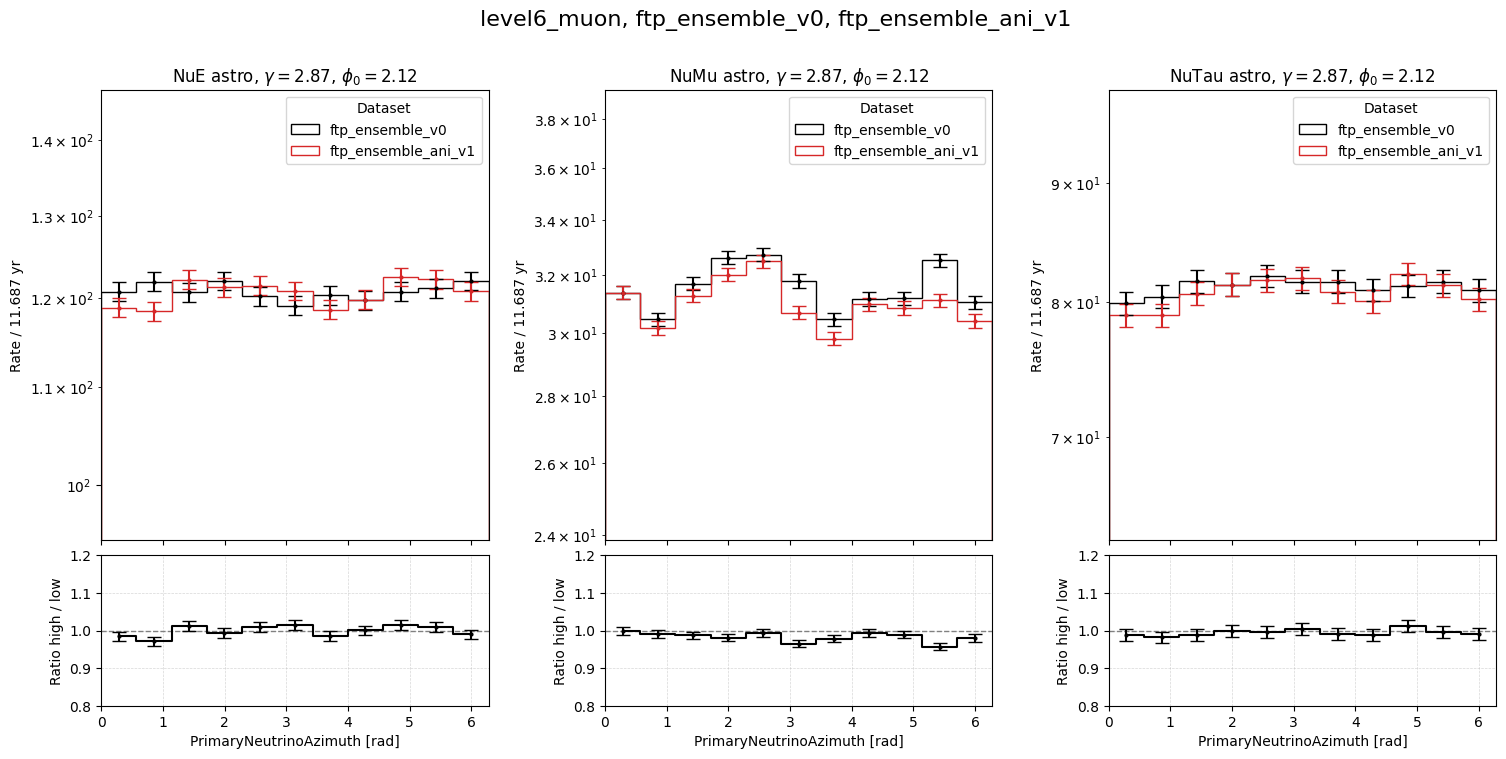

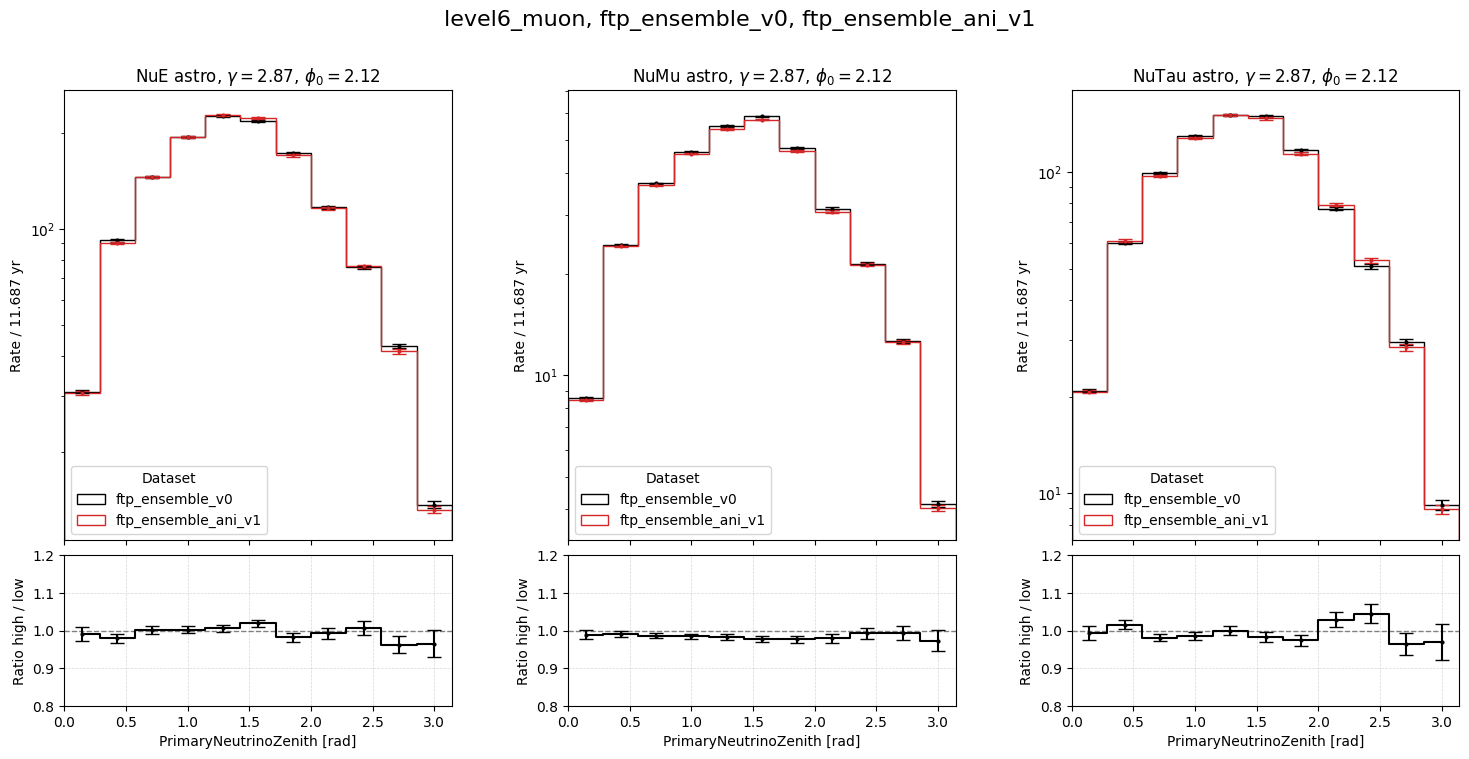

/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/notebooks/documentation/advanced_plotting.py:158: RuntimeWarning: invalid value encountered in divide
  ratio = hist_alt / hist_base
/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/notebooks/documentation/advanced_plotting.py:175: RuntimeWarning: invalid value encountered in divide
  (hist_base_error / hist_base)**2 + (hist_alt_error / hist_alt)**2
/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/notebooks/documentation/advanced_plotting.py:184: UserWarning: Attempt to set non-positive ylim on a log-scaled axis will be ignored.
  ax.set_ylim(0.8 * np.min([hist_base.min(), hist_alt.min()]),


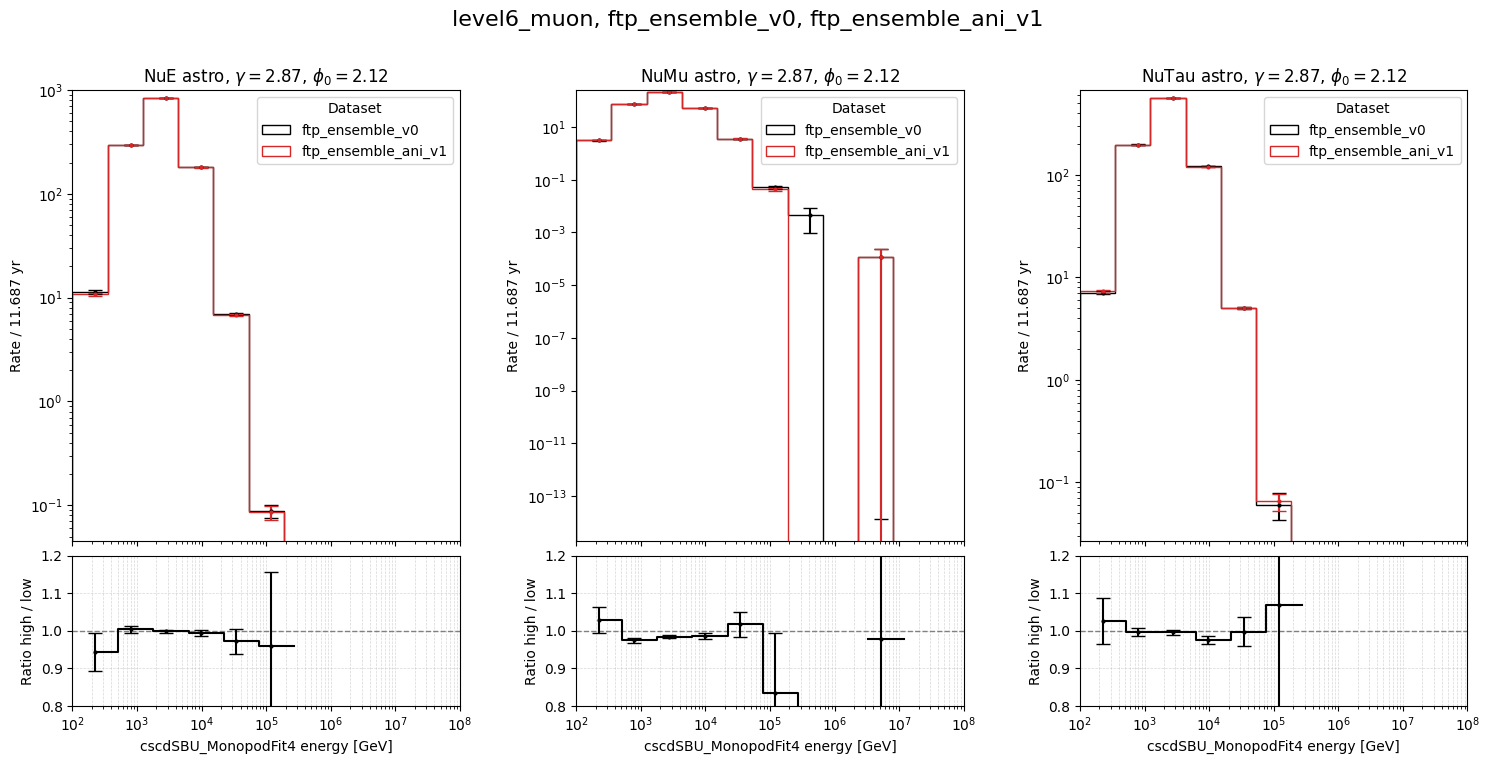

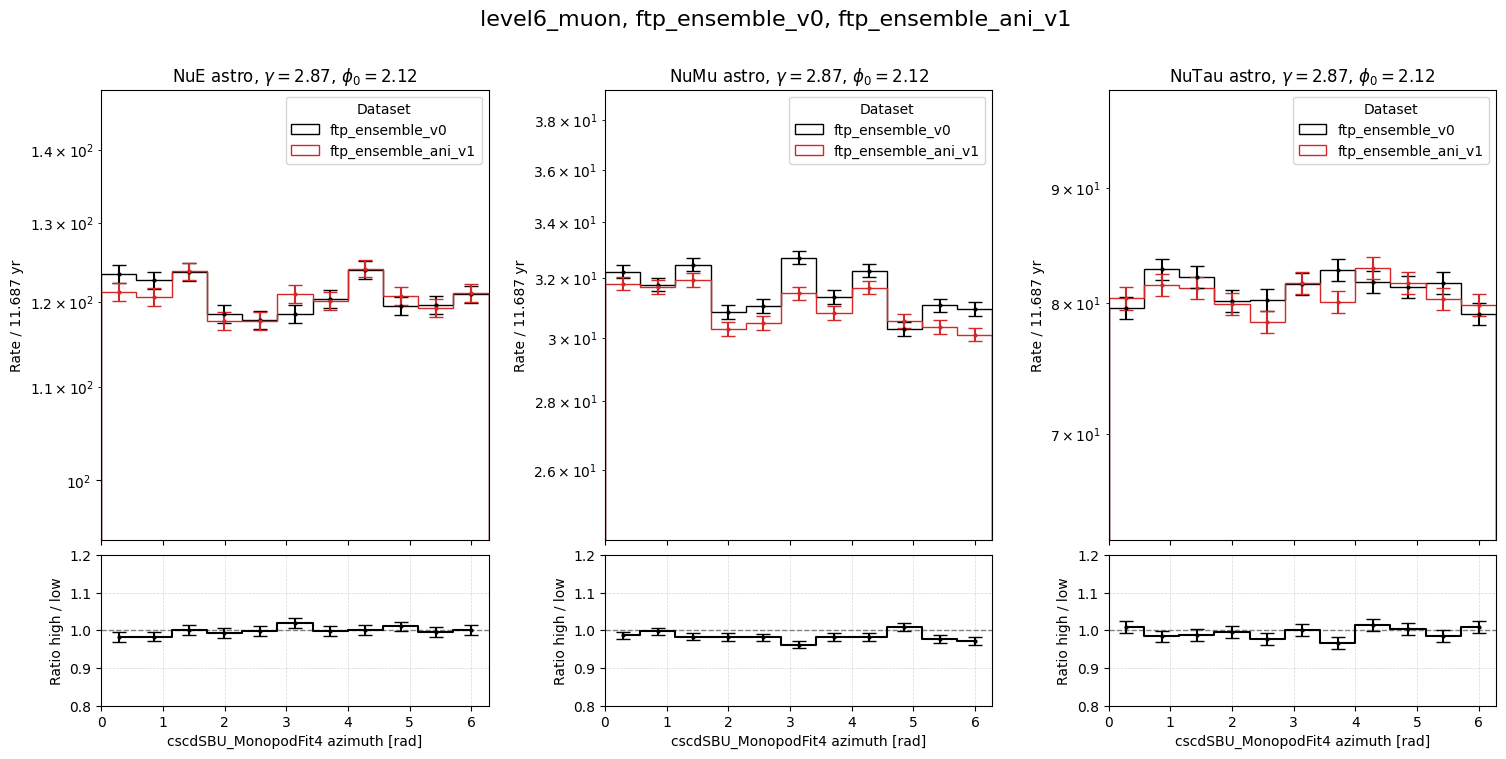

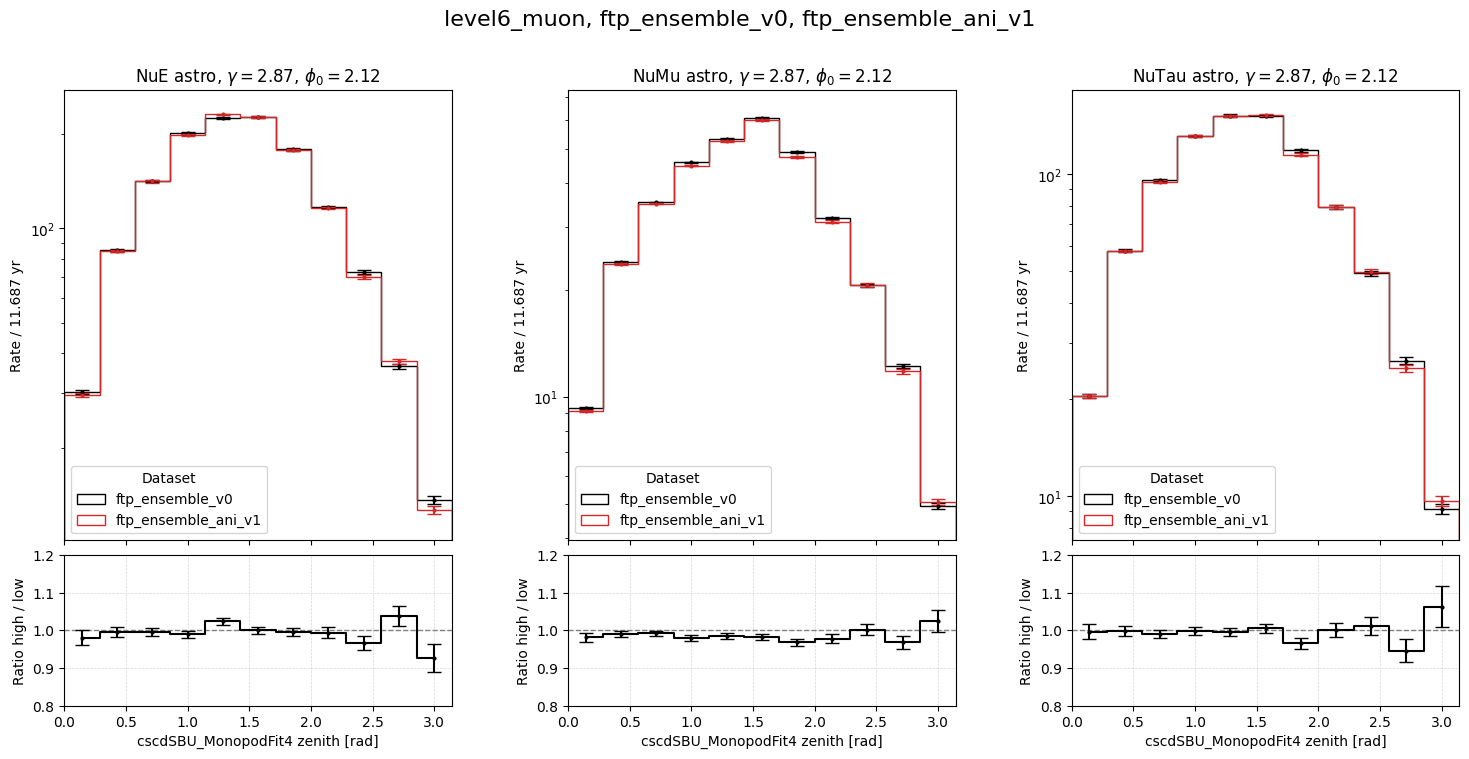

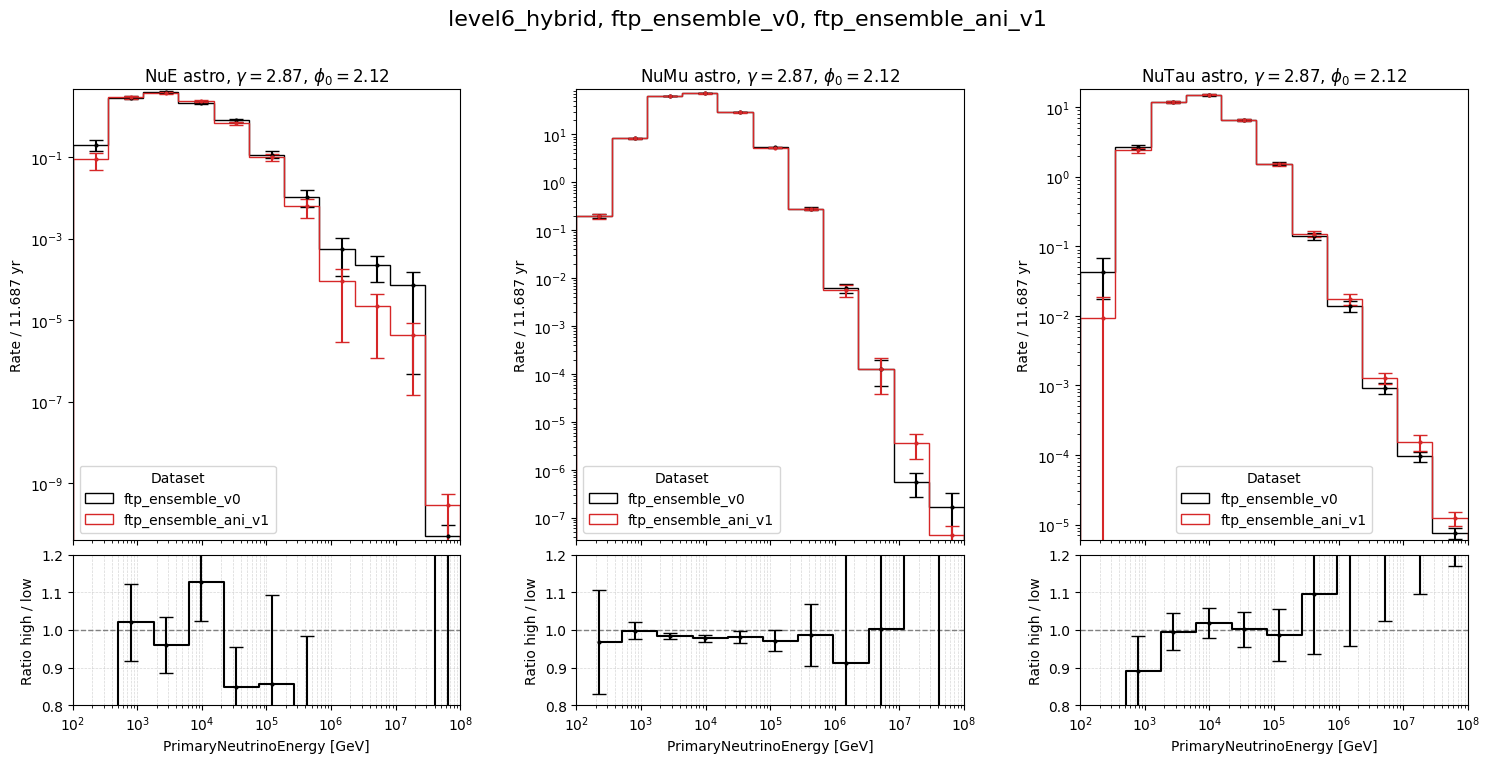

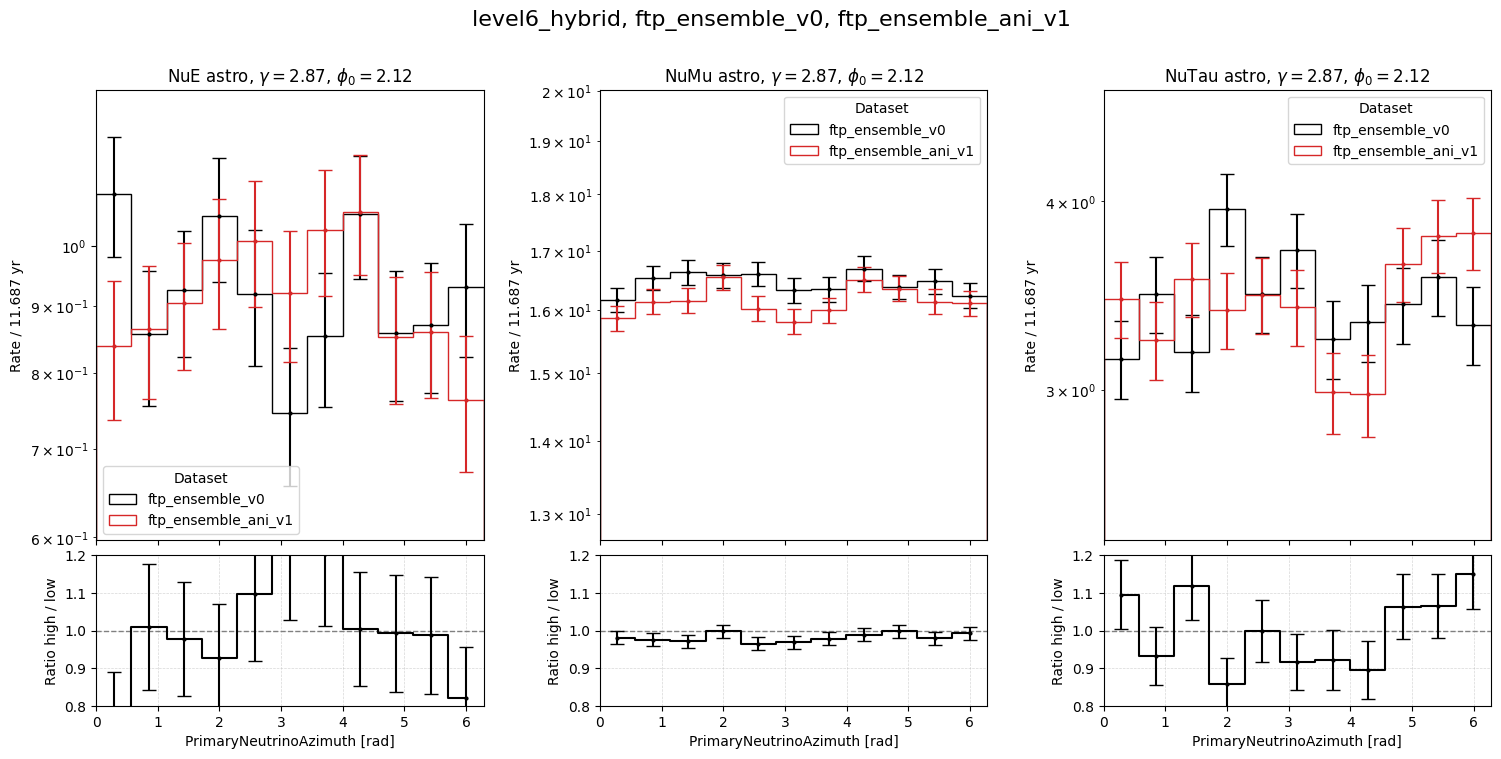

/mnt/ceph1-npx/user/tvaneede/GlobalFit/reco_processing/notebooks/documentation/advanced_plotting.py:158: RuntimeWarning: divide by zero encountered in divide
  ratio = hist_alt / hist_base


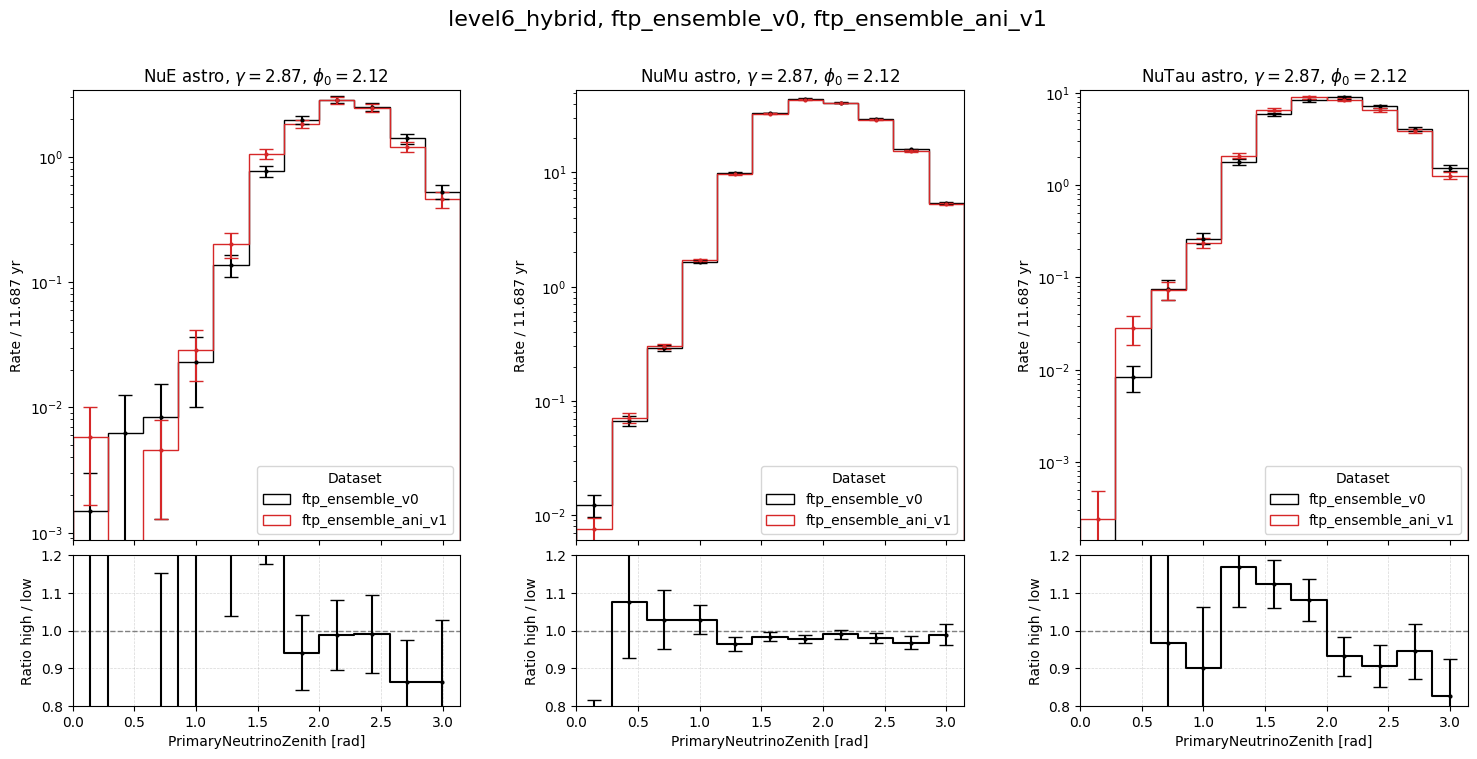

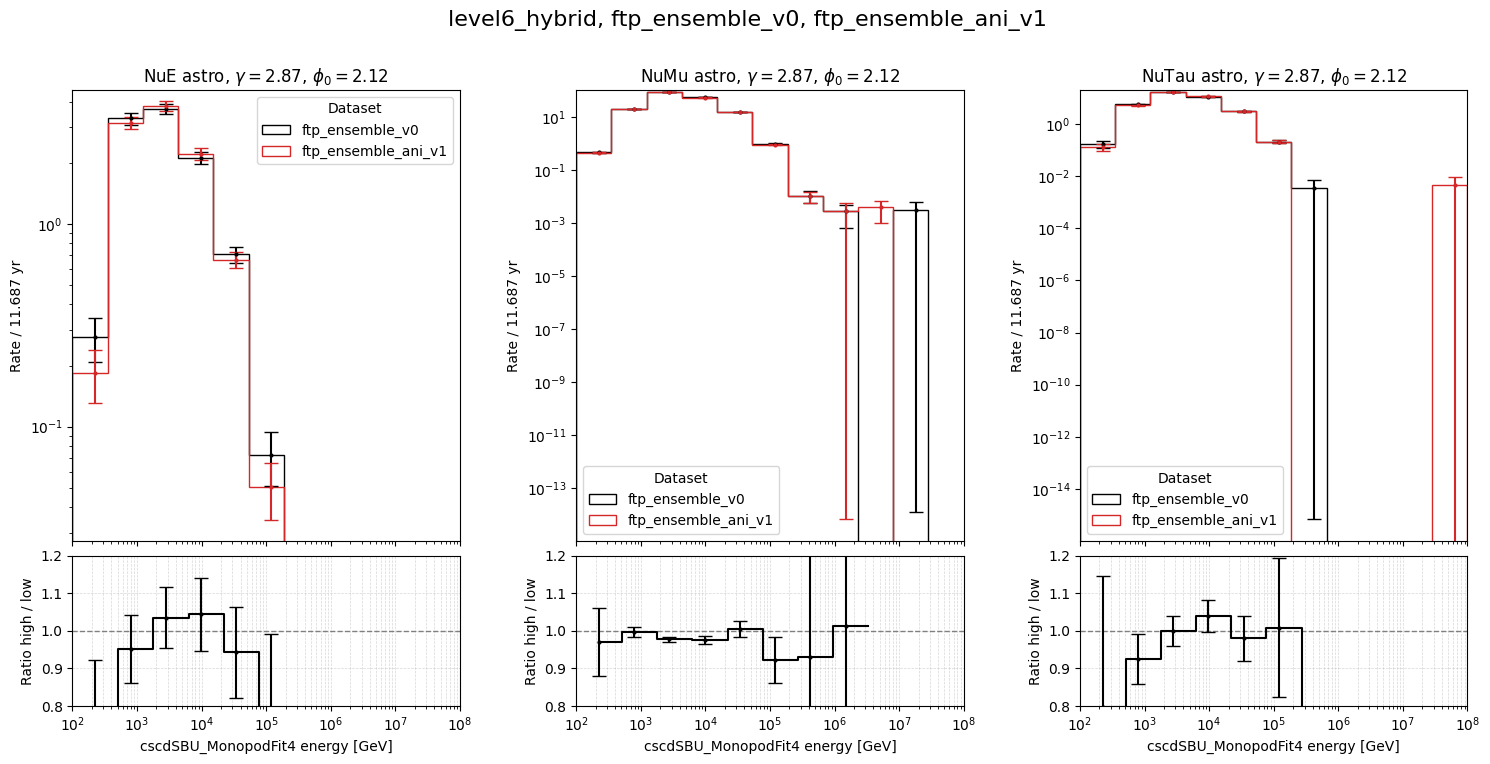

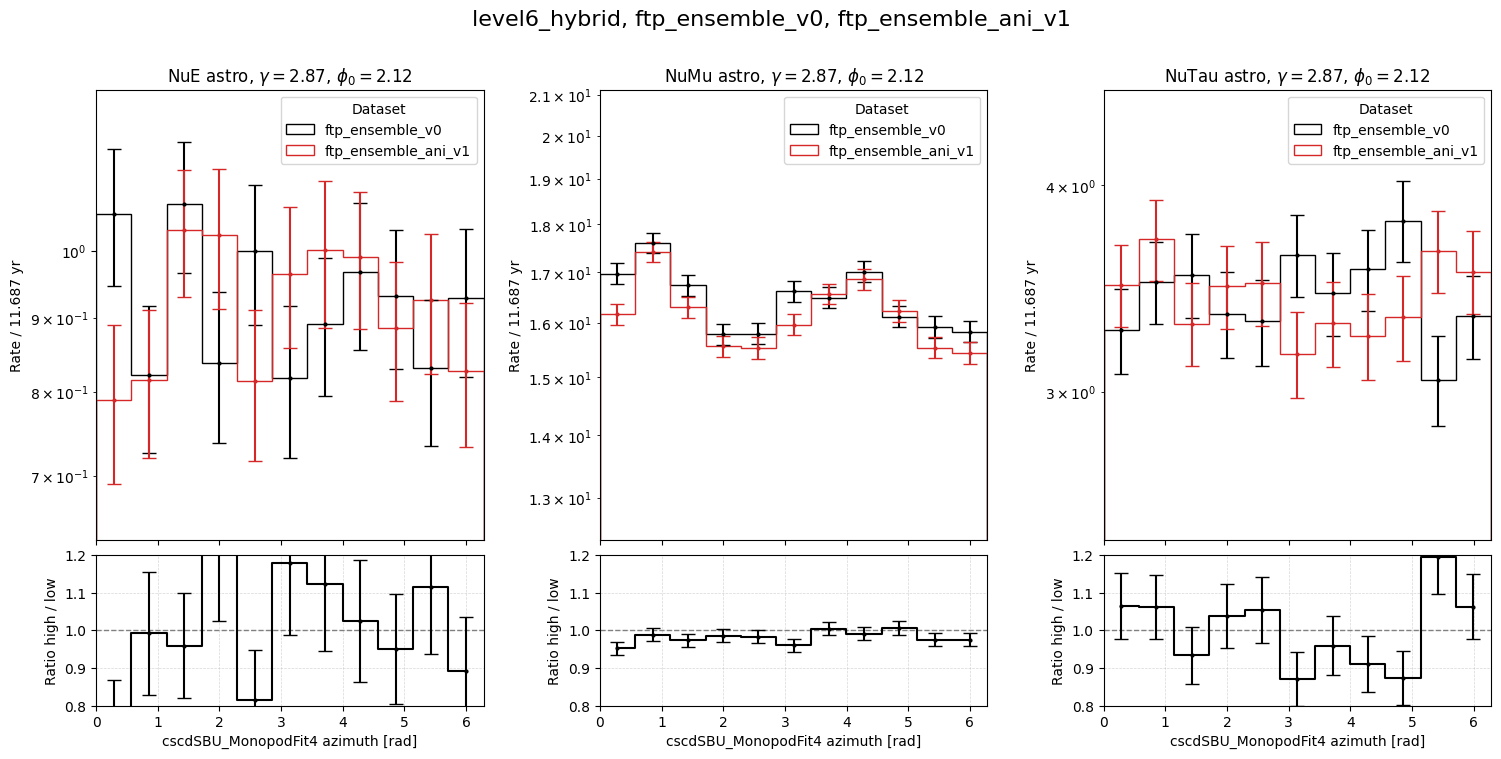

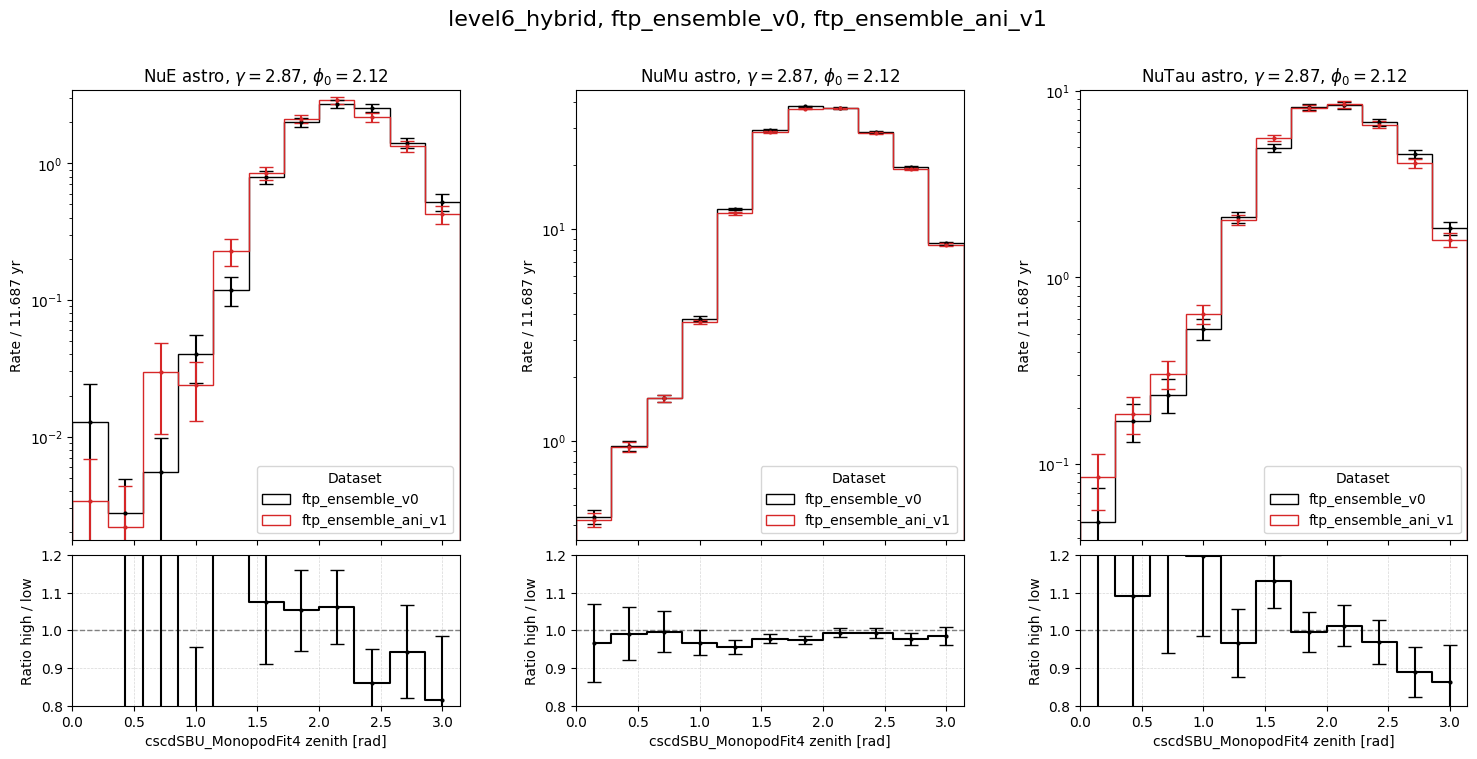

In [56]:
###
### Compare ensemble philipp and me
###
from advanced_plotting import *
from variables import variables
from systematics import systematics

levels = ["level6_cascade","level6_muon","level6_hybrid"]
# levels = ["level6_cascade"]

base_key = "ftp_ensemble_v0"
alt_key = "ftp_ensemble_ani_v1"

outpath = f"/data/user/tvaneede/GlobalFit/reco_processing/notebooks/documentation/plots/snowstorm/compare_dataset_flavor/{base_key}-{alt_key}"

for level in levels:
    for plot_name, variable_settings in variables[level].items():
            
        plotting_path = f"{outpath}/{level}"
        os.system(f"mkdir -p {plotting_path}")
        plotting_path = f"{plotting_path}/{plot_name}.png"

        variable_settings["alt_var_key1"] = variable_settings["base_var_key1"]
        variable_settings["alt_var_key2"] = variable_settings["base_var_key2"]

        compare_dataset_flavor(
        simulation_datasets, 
        base_key = base_key,
        base_level = level,
        alt_key = alt_key,
        alt_level = level,
        **variable_settings,
        livetime_yr = livetime_yr,
        flux_gamma = 2.87,
        flux_norm  = 2.12,
        plotting_path = plotting_path)

    #     break
    # break